# Market Impact Scenarios and Capacity Analysis

**Docker image**: `ml4t`

**Market impact** is the part of trading cost an order creates for itself: buying consumes the
offers resting in the book, so the last share pays a worse price than the first. Unlike
commission and spread it grows with size, which makes it the thing that decides how much money a
strategy can run before its own trading eats the edge - its **capacity**.

The standard model says impact grows with the square root of the **participation rate**, the
fraction of a day's volume an order represents. This notebook writes that model down, shows what
calibrating its coefficient would actually take, measures how far minute-by-minute market data
gets you towards one, shows when during the day the volume is there to trade against, and turns
the model into a capacity figure for the markets whose data supports one.

**Learning Objectives:**
- Write down the square-root impact model, name each of its inputs, and say which you can read
  off market data and which needs records of your own executions
- Measure how a stock's price moves against the direction of trading within a minute, and say why
  that measurement cannot establish that the trading caused the move
- Read a slope estimated across a cross-section together with its uncertainty, rather than off
  the point estimate alone
- Read an intraday volume profile and say what it implies for an order of fixed size
- Compute how much capital a strategy can run before impact consumes a stated gross return, and
  name every assumption that number rests on

**Book Reference:** Chapter 18, Sections 18.3, 18.4, and 18.8

**Prerequisites:** Access to six market panels, VIX, and licensed NASDAQ-100 minute bars with
tick-direction volume fields.

In [1]:
"""Unit-aware market-impact scenarios and capacity analysis."""

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from _cost_analysis import (
    compute_adv,
    estimate_kyle_lambda,
)
from IPython.display import Markdown, display

from data import (
    load_cme_futures,
    load_crypto_perps,
    load_etfs,
    load_fx_pairs,
    load_macro,
    load_nasdaq100_bars,
    load_sp500_daily_bars,
)
from utils.paths import REPO_ROOT
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

In [2]:
MAX_SYMBOLS = 50
SEED = 42
NQ100_SYMBOLS = 100
NQ100_START_DATE = "2021-10-01"
NQ100_END_DATE = "2021-12-31"
VOL_WINDOW = 20
ADV_WINDOW = 20
GROSS_ALPHA_BPS = 50
TURNOVER_PER_REBALANCE = 0.30
MAX_FEASIBLE_PARTICIPATION = 0.20
MODEL_REFERENCE_PARTICIPATION = 0.01
PLOT_CLIP_QUANTILE = 0.005

In [3]:
set_global_seeds(SEED)

What each setting decides:

- `MAX_SYMBOLS` caps how many instruments each descriptive panel contributes, and `NQ100_SYMBOLS`
  caps the minute-bar sample. `NQ100_START_DATE` and `NQ100_END_DATE` bound that sample to one
  quarter, which is what the licensed minute data can be read in without a long load.
- `VOL_WINDOW` and `ADV_WINDOW` are both 20 sessions, so volatility and average daily volume are
  each measured over roughly a trading month. They set how quickly the impact model's inputs
  respond to a change in market conditions.
- `GROSS_ALPHA_BPS` is the return per rebalance a strategy earns before costs, and
  `TURNOVER_PER_REBALANCE` is the fraction of its capital it trades to get it. Together they fix
  how much impact the strategy can absorb: at 50 bps of gross return, an order that costs 50 bps
  of impact leaves nothing.
- `MAX_FEASIBLE_PARTICIPATION` is the largest share of daily volume the capacity curves are drawn
  over. It is a stated limit on where the model is being asked to apply, not an estimate of where
  trading becomes impossible; the square-root law was fitted on far smaller orders than that.
- `MODEL_REFERENCE_PARTICIPATION` is the participation rate at which the linear and square-root
  models are matched, so that the comparison between them isolates their shape.
- `PLOT_CLIP_QUANTILE` hides the most extreme observations at each end of both axes of the
  single-symbol scatter, so the bulk of the cloud is visible. Every fit uses all observations.

## 1. Descriptive Market Panels

Impact is a fraction of price, so comparing it across markets means getting each market's volume
into a common unit first, and that is not always possible. Shares times a traded price is dollars
traded. Contracts times a price needs the contract multiplier. A count of price updates, which is
what the FX feed records as volume, is not convertible at all. The panels below are assembled in
their own units, and the table at the end of the section records which of them a dollar capacity
figure can be computed for.

Each panel is trimmed to its most active instruments by volume over the whole sample, which uses
information from the end of the window to choose what to include at the start. That is acceptable
for describing a set of liquid instruments and would not be acceptable inside a backtest.

In [4]:
def keep_top_symbols(df: pl.DataFrame, entity_col: str) -> pl.DataFrame:
    """Restrict a descriptive panel to its most active entities."""
    if MAX_SYMBOLS <= 0:
        return df
    top = df.group_by(entity_col).agg(pl.col("volume").mean()).sort("volume", descending=True)
    top_entities = top.head(MAX_SYMBOLS)[entity_col].to_list()
    return df.filter(pl.col(entity_col).is_in(top_entities))

### Rolling Descriptive Features

The impact model needs two quantities per instrument per day: how volatile it is and how much of
it trades. Both are computed as trailing 20-session windows, and both windows end on the current
day rather than the day before. That makes them a description of the sample. A strategy deciding
how to trade on a given morning would have to use the window that ended the previous close,
because that day's volume and range are not known until it is over.

In [5]:
def add_impact_features(
    df: pl.DataFrame,
    entity_col: str,
    time_col: str = "timestamp",
) -> pl.DataFrame:
    """Add returns, native-unit ADV, and volatility within each entity."""
    return df.sort([entity_col, time_col]).with_columns(
        ret=pl.col("close").pct_change().over(entity_col),
        adv_native=compute_adv(pl.col("volume"), ADV_WINDOW).over(entity_col),
        sigma=pl.col("close")
        .pct_change()
        .over(entity_col)
        .rolling_std(VOL_WINDOW)
        .over(entity_col),
    )

### ETF and Crypto Panels

ETF adjusted prices and observed share volume cannot reconstruct historical dollar turnover.
Crypto quote turnover is valid only when price times base volume is summed bar by bar.

In [6]:
daily_stats = {}
entity_cols = {}
time_cols = {}
volume_units = {}

etfs = keep_top_symbols(load_etfs(), "symbol")
daily_stats["ETFs"] = add_impact_features(etfs, "symbol")
entity_cols["ETFs"], time_cols["ETFs"] = "symbol", "timestamp"
volume_units["ETFs"] = "shares with adjusted price; no historical USD notional"

crypto = keep_top_symbols(load_crypto_perps(frequency="8h"), "symbol")
crypto_daily = (
    crypto.sort(["symbol", "timestamp"])
    .with_columns(
        activity_date=pl.col("timestamp").dt.date(),
        bar_turnover_usd=pl.col("close") * pl.col("volume"),
    )
    .group_by(["symbol", "activity_date"])
    .agg(
        close=pl.col("close").last(),
        volume=pl.col("volume").sum(),
        daily_turnover_usd=pl.col("bar_turnover_usd").sum(),
    )
    .rename({"activity_date": "timestamp"})
)
daily_stats["Crypto Perps"] = add_impact_features(crypto_daily, "symbol")
entity_cols["Crypto Perps"], time_cols["Crypto Perps"] = "symbol", "timestamp"
volume_units["Crypto Perps"] = "base asset; bar-level conversion to USDT turnover"

### CME Futures Panel

Futures volume counts contracts. Dollar turnover requires the product multiplier, derived from
tick value divided by tick size. Returns use roll-adjusted prices; notional uses raw traded prices.

In [7]:
spec_path = REPO_ROOT / "data" / "futures" / "market" / "futures_specs.yaml"
product_specs = yaml.safe_load(spec_path.read_text())["products"]
multiplier_df = pl.DataFrame(
    [
        {
            "product": product,
            "price_multiplier": float(spec["tick_value"]) / float(spec["tick_size"]),
        }
        for product, spec in product_specs.items()
    ]
)

futures = load_cme_futures(tenors=[0]).rename({"session_date": "timestamp"})
futures = keep_top_symbols(futures, "product").join(
    multiplier_df,
    on="product",
    how="left",
)
missing_multipliers = futures.filter(pl.col("price_multiplier").is_null())["product"].unique()
if len(missing_multipliers) > 0:
    raise ValueError(f"Missing CME multipliers for: {sorted(missing_multipliers.to_list())}")

In [8]:
cme_daily = futures.select(
    "product",
    "timestamp",
    pl.col("adj_close").alias("close"),
    "raw_close",
    "volume",
    "price_multiplier",
).with_columns(
    daily_turnover_usd=pl.col("volume") * pl.col("raw_close") * pl.col("price_multiplier")
)
daily_stats["CME Futures"] = add_impact_features(cme_daily, "product")
entity_cols["CME Futures"], time_cols["CME Futures"] = "product", "timestamp"
volume_units["CME Futures"] = "contracts; multiplier-adjusted USD notional"

### FX and S&P 500 Panels

OANDA volume is tick activity, so FX remains outside dollar-capacity comparisons. S&P 500 bars
pair traded prices with share volume and support row-level dollar turnover.

In [9]:
fx = keep_top_symbols(load_fx_pairs(frequency="daily"), "symbol")
daily_stats["FX Pairs"] = add_impact_features(fx, "symbol")
entity_cols["FX Pairs"], time_cols["FX Pairs"] = "symbol", "timestamp"
volume_units["FX Pairs"] = "OANDA ticks; no traded notional"

sp500 = keep_top_symbols(load_sp500_daily_bars(), "symbol").with_columns(
    daily_turnover_usd=pl.col("close") * pl.col("volume")
)
daily_stats["S&P 500 Equities"] = add_impact_features(sp500, "symbol")
entity_cols["S&P 500 Equities"], time_cols["S&P 500 Equities"] = "symbol", "timestamp"
volume_units["S&P 500 Equities"] = "shares; traded-price USD notional"

### NASDAQ-100 Daily Panel

The loader's default path keeps regular-session bars. Sorting before `last()` makes the daily
close explicit rather than relying on input order.

In [10]:
nq_daily = (
    load_nasdaq100_bars(
        start_date=NQ100_START_DATE,
        end_date=NQ100_END_DATE,
        lazy=True,
    )
    .select("timestamp", "symbol", "close", "volume")
    .sort(["symbol", "timestamp"])
    .with_columns(activity_date=pl.col("timestamp").dt.date())
    .group_by(["symbol", "activity_date"])
    .agg(close=pl.col("close").last(), volume=pl.col("volume").sum())
    .rename({"activity_date": "timestamp"})
    .collect()
    .sort(["symbol", "timestamp"])
)
nq_daily = keep_top_symbols(nq_daily, "symbol").with_columns(
    daily_turnover_usd=pl.col("close") * pl.col("volume")
)
daily_stats["NASDAQ-100"] = add_impact_features(nq_daily, "symbol")
entity_cols["NASDAQ-100"], time_cols["NASDAQ-100"] = "symbol", "timestamp"
volume_units["NASDAQ-100"] = "shares; traded-price USD notional"

### Panel Contract

Different histories and native units prevent a market-wide ranking. This table makes the sample
scope explicit before any scenario is plotted.

In [11]:
panel_summary = pl.DataFrame(
    [
        {
            "market": name,
            "rows": len(df),
            "entities": df[entity_cols[name]].n_unique(),
            "start": df[time_cols[name]].min(),
            "end": df[time_cols[name]].max(),
            "volume_contract": volume_units[name],
            "supports_usd_capacity": "daily_turnover_usd" in df.columns,
        }
        for name, df in daily_stats.items()
    ]
)
panel_summary

market,rows,entities,start,end,volume_contract,supports_usd_capacity
str,i64,i64,date,date,str,bool
"""ETFs""",236266,50,2006-01-03,2025-12-31,"""shares with adjusted price; no…",false
"""Crypto Perps""",36109,19,2020-01-01,2025-12-31,"""base asset; bar-level conversi…",true
"""CME Futures""",113506,30,2011-01-03,2025-12-31,"""contracts; multiplier-adjusted…",true
"""FX Pairs""",77480,20,2011-01-03,2025-12-31,"""OANDA ticks; no traded notiona…",false
"""S&P 500 Equities""",52120,50,2017-01-03,2021-12-31,"""shares; traded-price USD notio…",true
"""NASDAQ-100""",3063,50,2021-10-01,2021-12-31,"""shares; traded-price USD notio…",true


**Interpretation**: The `supports_usd_capacity` column is what decides which markets appear in
the capacity section later. Crypto, CME futures with their multipliers applied, and the two US
equity panels reach a dollar figure; the ETF and FX panels do not, for the reasons their
`volume_contract` entries give.

## 2. Square-Root Impact Scenarios

The model that most institutional cost estimates start from is

$$\text{Impact} = \sigma \cdot \eta \cdot \sqrt{\frac{Q}{V}}$$

where $\sigma$ is the instrument's daily volatility, $Q$ is the size of the order, $V$ is its
average daily volume, and $\eta$ is a coefficient that has to come from somewhere else.

Each of the first three is measurable from market data. $\eta$ is not: it says how much of the
volatility a given participation rate consumes, and the only way to observe that is to compare
what your own orders paid against the price when you decided to send them. Almgren, R., Thum, C.,
Hauptmann, E., and Li, H., "Direct Estimation of Equity Market Impact", *Risk* 18(7), 58-62, sets
out that procedure and what it requires.

There are no execution records here, so the coefficients below are stated rather than estimated.
They are round figures ordered by how much impact each market is generally expected to show, and
the point of the section is what the model does with them, not what they are.

In [12]:
ETA_SCENARIO = {
    "ETFs": 0.10,
    "S&P 500 Equities": 0.15,
    "NASDAQ-100": 0.12,
    "CME Futures": 0.08,
    "Crypto Perps": 0.30,
    "FX Pairs": 0.05,
}

scenario_rows = []
for name, df in daily_stats.items():
    valid = df.filter(pl.col("sigma").is_not_null() & (pl.col("sigma") > 0))
    med_sigma = valid["sigma"].median()
    if med_sigma is None:
        continue
    eta = ETA_SCENARIO[name]
    scenario_rows.append(
        {
            "market": name,
            "eta_assumption": eta,
            "median_daily_sigma": med_sigma,
            "impact_ref_bps": (med_sigma * eta * np.sqrt(MODEL_REFERENCE_PARTICIPATION) * 10_000),
            "observations": len(valid),
        }
    )

scenario_df = pl.DataFrame(scenario_rows).sort("impact_ref_bps")
scenario_df

market,eta_assumption,median_daily_sigma,impact_ref_bps,observations
str,f64,f64,f64,i64
"""FX Pairs""",0.05,0.004876,0.243821,77080
"""CME Futures""",0.08,0.009335,0.746775,112906
"""ETFs""",0.1,0.010267,1.026656,235266
"""NASDAQ-100""",0.12,0.018784,2.254037,2085
"""S&P 500 Equities""",0.15,0.017563,2.634474,51120
"""Crypto Perps""",0.3,0.044143,13.242851,35634


**Interpretation**: Two things drive the differences between these rows, and only one of them was
measured. `median_daily_sigma` comes from each panel's own price history; `eta_assumption` was
typed in above. A market that appears expensive here is expensive under an assumption that was
chosen, and the table separates the two columns so that stays visible.

### Scenario Curves

The same model drawn across a range of participation rates. What the square root does to the
shape is the point: the curve is steepest where the order is smallest, so the first slice of
participation costs proportionally more than the last, and doubling the order size raises the
cost per dollar traded by about forty percent rather than doubling it.

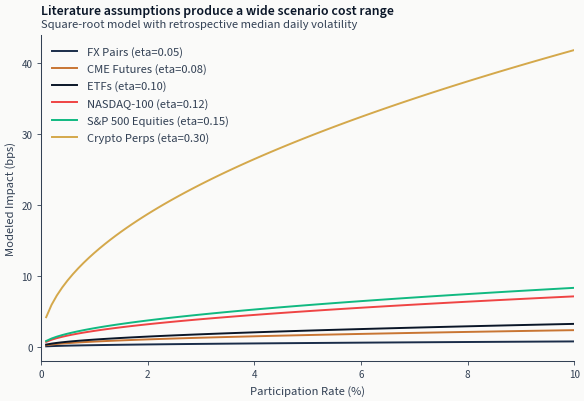

In [13]:
participation_rates = np.linspace(0.001, 0.10, 100)
market_colors = {
    "ETFs": COLORS["blue"],
    "Crypto Perps": COLORS["amber"],
    "CME Futures": COLORS["copper"],
    "FX Pairs": COLORS["slate"],
    "S&P 500 Equities": COLORS["positive"],
    "NASDAQ-100": COLORS["negative"],
}

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
for row in scenario_df.iter_rows(named=True):
    name = row["market"]
    eta = row["eta_assumption"]
    med_sigma = row["median_daily_sigma"]
    impact_bps = med_sigma * eta * np.sqrt(participation_rates) * 10_000
    ax.plot(
        participation_rates * 100,
        impact_bps,
        color=market_colors[name],
        label=f"{name} (eta={eta:.2f})",
    )

ax.set_xlabel("Participation Rate (%)")
ax.set_ylabel("Modeled Impact (bps)")
add_message_title(
    ax,
    "Literature assumptions produce a wide scenario cost range",
    subtitle="Square-root model with retrospective median daily volatility",
)
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(0, 10)

show_with_alt(
    fig,
    "Six impact curves against participation rate, one per market. All rise steeply from the "
    "origin and flatten as participation grows, and they are separated by more than an order of "
    "magnitude, with crypto highest and FX lowest.",
)

In [14]:
lowest_scenario = scenario_df.row(0, named=True)
highest_scenario = scenario_df.row(-1, named=True)
display(
    Markdown(
        f"**Scenario reading:** At {MODEL_REFERENCE_PARTICIPATION:.0%} participation, modeled "
        f"impact spans {lowest_scenario['impact_ref_bps']:.2f} bps for "
        f"{lowest_scenario['market']} to {highest_scenario['impact_ref_bps']:.2f} bps for "
        f"{highest_scenario['market']}, a factor of "
        f"{highest_scenario['impact_ref_bps'] / lowest_scenario['impact_ref_bps']:.0f}. Both the "
        "volatility and the stated coefficient contribute to that spread."
    )
)

**Scenario reading:** At 1% participation, modeled impact spans 0.24 bps for FX Pairs to 13.24 bps for Crypto Perps, a factor of 54. Both the volatility and the stated coefficient contribute to that spread.

## 3. How Far Market Data Gets You Toward a Coefficient

Section 2 said $\eta$ needs your own execution records. This section asks what can be measured
without them, using the closest thing public market data offers: whether trading in one direction
is accompanied by the price moving that way.

Which side initiated a trade is not recorded on the tape, so it is inferred. The **tick rule**
calls a trade buyer-initiated if it printed above the previous trade and seller-initiated if it
printed below, on the reasoning that a buyer in a hurry lifts the offer and a seller hits the bid.
The minute bars carry uptick and downtick volume already classified that way, and their difference
is the minute's **signed order flow**: positive when more volume traded on upticks than downticks.

Regressing the minute's return on that signed flow gives a slope in the units of the model:

$$r_t^{bps} = \lambda_{part}\left(10^4\frac{Q_t}{ADV}\right) + \varepsilon_t.$$

Dividing flow by average daily volume before scaling both sides to basis points is what makes the
slope comparable across stocks: a hundred-dollar stock and a ten-dollar stock move by different
numbers of cents for the same percentage move, and a thousand shares means something different in
each.

What the slope is not is an impact estimate. Both quantities are measured over the same minute,
so nothing in the data says the flow came first. A minute in which good news arrives will show
buying and a price rise together, with the news causing both. Section 18.4 of the chapter draws
the distinction the data cannot: **temporary impact**, which decays once the order stops, against
**permanent impact**, which is the information the trading revealed.

### Restore the Regular Session

The microstructure feed deliberately bypasses the loader's clock filter, so the 09:30 to 16:00 ET
session is restored here before symbols are ranked or slopes fitted. Volume outside those hours
is thin and trades at wide spreads, so leaving it in would put the noisiest minutes of the day
into every regression.

In [15]:
def regular_session_mask(timestamp_col: str = "timestamp") -> pl.Expr:
    """Return the documented US-equity regular-session mask."""
    hour = pl.col(timestamp_col).dt.hour()
    minute = pl.col(timestamp_col).dt.minute()
    return ((hour > 9) | ((hour == 9) & (minute >= 30))) & (hour < 16)

### Load and Reconcile the Signed-Flow Sample

In [16]:
def session_integrity_ledger(
    raw: pl.DataFrame,
    regular: pl.DataFrame,
    selected: pl.DataFrame,
) -> pl.DataFrame:
    """Reconcile raw, session-filtered, and selected minute rows."""
    unique_keys = selected.select(pl.struct("symbol", "timestamp").n_unique()).item()
    return pl.DataFrame(
        {
            "population": [
                "Raw rows",
                "Outside regular session",
                "Regular rows",
                "Selected rows",
                "Duplicate keys",
            ],
            "rows": [
                len(raw),
                len(raw) - len(regular),
                len(regular),
                len(selected),
                len(selected) - unique_keys,
            ],
        }
    )

In [17]:
def load_nq_signed_flow_sample() -> tuple[pl.DataFrame, pl.DataFrame]:
    """Load a regular-session liquid sample and its row-conservation ledger."""
    raw = load_nasdaq100_bars(
        start_date=NQ100_START_DATE,
        end_date=NQ100_END_DATE,
        include_microstructure=True,
    ).select(
        "timestamp",
        "symbol",
        "volume",
        "last_trade_price",
        "uptick_volume",
        "downtick_volume",
    )
    regular = raw.filter(regular_session_mask())
    n_symbols = NQ100_SYMBOLS if NQ100_SYMBOLS > 0 else regular["symbol"].n_unique()
    top_symbols = (
        regular.group_by("symbol")
        .agg(pl.col("volume").sum())
        .sort("volume", descending=True)
        .head(n_symbols)["symbol"]
        .to_list()
    )
    selected = regular.filter(pl.col("symbol").is_in(top_symbols))
    return selected, session_integrity_ledger(raw, regular, selected)

In [18]:
nq_micro, nq_integrity = load_nq_signed_flow_sample()
if nq_micro.is_empty():
    raise ValueError("No regular-session NASDAQ-100 microstructure rows in the selected window.")
nq_integrity

population,rows
str,i64
"""Raw rows""",6154809
"""Outside regular session""",3612399
"""Regular rows""",2542410
"""Selected rows""",2428530
"""Duplicate keys""",0


The symbols are ranked by volume over the whole quarter, so this is a description of a liquid
late-2021 sample rather than a universe anyone could have selected in advance.

### Build Tick-Rule Signed Flow

The return has to be measured over the same minute as the flow it is paired with, which means the
previous price is the previous minute **of the same session**. Carrying it across a session
boundary would pair the first minute's flow with the overnight move, and an overnight move is a
different quantity by an order of magnitude: it accumulates fifteen hours of news while the
market was closed and nobody could trade on it. The first minute of each day therefore has no
prior price and drops out.

In [19]:
nq_flow = (
    nq_micro.sort(["symbol", "timestamp"])
    .filter(
        pl.col("last_trade_price").is_not_null()
        & (pl.col("last_trade_price") > 0)
        & pl.col("uptick_volume").is_not_null()
        & pl.col("downtick_volume").is_not_null()
    )
    .with_columns(session_date=pl.col("timestamp").dt.date())
    .with_columns(prior_price=pl.col("last_trade_price").shift(1).over(["symbol", "session_date"]))
    .with_columns(
        signed_volume=(pl.col("uptick_volume") - pl.col("downtick_volume")).cast(pl.Float64),
        price_return_bps=(pl.col("last_trade_price") / pl.col("prior_price") - 1) * 10_000,
    )
    .filter(
        pl.col("price_return_bps").is_not_null()
        & pl.col("price_return_bps").is_finite()
        & pl.col("signed_volume").is_not_null()
        & (pl.col("signed_volume") != 0)
    )
)

flow_summary = pl.DataFrame(
    {
        "regular_rows": [len(nq_micro)],
        "signed_flow_rows": [len(nq_flow)],
        "sessions": [nq_flow["session_date"].n_unique()],
        "symbols": [nq_flow["symbol"].n_unique()],
    }
)
flow_summary

regular_rows,signed_flow_rows,sessions,symbols
i64,i64,i64,i64
2428530,2404371,64,100


### Estimate a Price-Normalized Coefficient

One regression per symbol, its signed flow divided by its own average daily share volume so the
slope is in the model's units on both sides.

The fit is a **Huber regression** rather than ordinary least squares. Least squares squares every
residual, so a handful of minutes in which the price jumped for an unrelated reason can set the
slope for a whole quarter. Huber squares small residuals and only takes the absolute value of
large ones, which caps how much any single minute can pull the line. The cost of that is that the
fitted line no longer minimizes squared error, so the R-squared reported beside it - which is
defined from squared error - can come out negative. That is not a failure of the fit; it says the
robust line deliberately declines to chase the outliers that a squared-error criterion rewards.

In [20]:
def estimate_normalized_lambda(symbol: str, flow: pl.DataFrame) -> dict | None:
    """Estimate return bps per signed-participation bps for one symbol."""
    sym_data = flow.filter(pl.col("symbol") == symbol)
    if len(sym_data) < 100:
        return None
    daily = (
        sym_data.with_columns(
            activity_date=pl.col("timestamp").dt.date(),
            dollar_turnover=pl.col("last_trade_price") * pl.col("volume"),
        )
        .group_by("activity_date")
        .agg(volume=pl.col("volume").sum(), dollar_turnover=pl.col("dollar_turnover").sum())
    )
    adv_shares = float(daily["volume"].mean())
    adv_usd = float(daily["dollar_turnover"].mean())
    scaled = sym_data.with_columns(
        signed_participation_bps=pl.col("signed_volume") / adv_shares * 10_000
    )
    fit = estimate_kyle_lambda(
        price_changes=scaled["price_return_bps"].to_numpy(),
        signed_volume=scaled["signed_participation_bps"].to_numpy(),
    )
    return {
        "symbol": symbol,
        "lambda_participation": fit["lambda_"],
        "r_squared": fit["r_squared"],
        "std_err": fit["std_err"],
        "n_obs": fit["n_obs"],
        "adv_shares": adv_shares,
        "adv_usd": adv_usd,
    }

In [21]:
lambda_results = []
for symbol in nq_flow["symbol"].unique().sort().to_list():
    result = estimate_normalized_lambda(symbol, nq_flow)
    if result is not None:
        lambda_results.append(result)
lambda_df = pl.DataFrame(lambda_results).filter(
    pl.col("lambda_participation").is_not_null()
    & pl.col("lambda_participation").is_finite()
    & (pl.col("adv_usd") > 0)
)
if lambda_df.is_empty():
    raise ValueError("No valid normalized signed-flow regressions were estimated.")

lambda_df.select(
    "symbol",
    "lambda_participation",
    "r_squared",
    "n_obs",
    "adv_usd",
).sort("lambda_participation")

symbol,lambda_participation,r_squared,n_obs,adv_usd
str,f64,f64,i64,f64
"""AAPL""",0.000407,0.000004,24892,5.9564e9
"""CMCSA""",0.000942,0.000152,24742,5.2810e8
"""KHC""",0.001976,0.000069,24752,1.2586e8
"""CHTR""",0.002253,-0.000538,24612,4.4338e8
"""CSX""",0.002269,0.000178,24720,2.2347e8
…,…,…,…,…
"""CHKP""",0.257231,-0.037049,21072,7.3986e7
"""CRWD""",0.293945,0.002912,24786,4.3483e8
"""LCID""",0.298717,0.014566,3500,5.4119e8


In [22]:
median_lambda = float(lambda_df["lambda_participation"].median())
median_r2 = float(lambda_df["r_squared"].median())
negative_lambda_count = lambda_df.filter(pl.col("lambda_participation") <= 0).height
display(
    Markdown(
        f"**Association summary:** {len(lambda_df)} symbols were fitted, of which "
        f"{negative_lambda_count} produced a negative slope - a name whose price moved against "
        "the direction of its own order flow over the quarter, which is the opposite of what the "
        f"impact model describes. The median slope is {median_lambda:.3f} return bps per basis "
        f"point of signed participation. The median R-squared is {median_r2:.4f}: essentially "
        "none of the minute-by-minute variation in returns is explained by signed flow, whatever "
        "the slope."
    )
)

**Association summary:** 100 symbols were fitted, of which 0 produced a negative slope - a name whose price moved against the direction of its own order flow over the quarter, which is the opposite of what the impact model describes. The median slope is 0.039 return bps per basis point of signed participation. The median R-squared is -0.0033: essentially none of the minute-by-minute variation in returns is explained by signed flow, whatever the slope.

### Normalized Association Versus Dollar Liquidity

If flow moves price the way the model says, a more liquid stock should move less for the same
participation, so the slope should fall as dollar turnover rises. Both quantities span orders of
magnitude, so the regression is run on their base-10 logarithms, where a straight line means a
power law and the slope is its exponent.

Two things about this regression have to be said before its output is read. The logarithm is
undefined for a negative slope, so the symbols whose fits came out negative are excluded, and the
count of them is reported below - selecting on the sign of the variable being explained tilts the
sample that remains. And the fit supplies a confidence interval from its own covariance estimate,
which is what the section reads, because a slope of the right sign means nothing if an interval
around it comfortably contains zero.

In [23]:
lambda_cross = lambda_df.filter(pl.col("lambda_participation") > 0).to_pandas()
dropped_for_log = len(lambda_df) - len(lambda_cross)
if len(lambda_cross) < 4:
    raise ValueError("Too few positive normalized coefficients for cross-sectional inference.")

log_adv = np.log10(lambda_cross["adv_usd"].to_numpy())
log_lambda = np.log10(lambda_cross["lambda_participation"].to_numpy())
coefficients, covariance = np.polyfit(log_adv, log_lambda, 1, cov=True)
slope, intercept = coefficients
slope_se = float(np.sqrt(covariance[0, 0]))
slope_low, slope_high = slope - 1.96 * slope_se, slope + 1.96 * slope_se
fitted = intercept + slope * log_adv
r_squared_cross = 1 - np.sum((log_lambda - fitted) ** 2) / np.sum(
    (log_lambda - log_lambda.mean()) ** 2
)

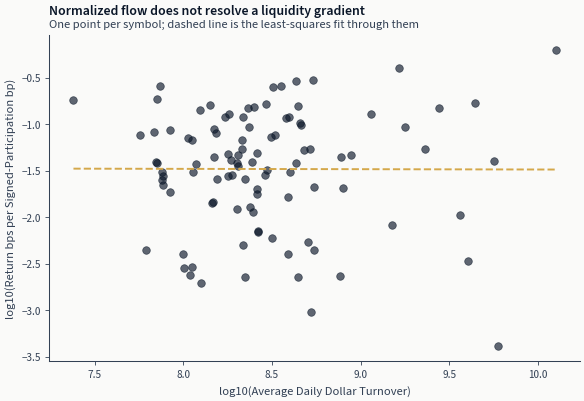

In [24]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.scatter(log_adv, log_lambda, color=COLORS["blue"], alpha=0.65, s=30)
x_line = np.linspace(log_adv.min(), log_adv.max(), 100)
ax.plot(x_line, intercept + slope * x_line, color=COLORS["amber"], linestyle="--")
ax.set_xlabel("log10(Average Daily Dollar Turnover)")
ax.set_ylabel("log10(Return bps per Signed-Participation bp)")
if slope_low <= 0 <= slope_high:
    slope_message = "Normalized flow does not resolve a liquidity gradient"
else:
    direction = "falls" if slope < 0 else "rises"
    slope_message = f"Normalized flow association {direction} with dollar liquidity"
add_message_title(
    ax,
    slope_message,
    subtitle="One point per symbol; dashed line is the least-squares fit through them",
)
show_with_alt(
    fig,
    "A scatter of the log slope against log average daily dollar turnover, one point per symbol, "
    "with a dashed least-squares line through it. The points form a wide cloud with no visible "
    "gradient, and the line is close to flat.",
)

In [25]:
interval_reading = "excludes zero" if slope_low * slope_high > 0 else "includes zero"
display(
    Markdown(
        f"**Cross-sectional reading:** Taking logs drops {dropped_for_log} of the "
        f"{len(lambda_df)} symbols for a non-positive slope, leaving {len(lambda_cross)}. Across "
        f"those, the log-log slope is {slope:.2f} with a 95% interval from {slope_low:.2f} to "
        f"{slope_high:.2f}, which {interval_reading}, and the regression R-squared is "
        f"{r_squared_cross:.3f}. On this sample the more liquid stocks show no smaller response "
        "to signed flow than the less liquid ones."
    )
)

**Cross-sectional reading:** Taking logs drops 0 of the 100 symbols for a non-positive slope, leaving 100. Across those, the log-log slope is -0.00 with a 95% interval from -0.26 to 0.25, which includes zero, and the regression R-squared is 0.000. On this sample the more liquid stocks show no smaller response to signed flow than the less liquid ones.

## 4. A Representative Symbol

The summary numbers above are medians across a hundred regressions, and a median hides what any
one of them looks like. The symbol whose slope is closest to the median is plotted below, one
point per minute, so the strength of the relationship is visible directly. The most extreme
observations at each end of both axes are hidden so the bulk of the cloud fills the frame; every
fit above used all of them.

In [26]:
rep_symbol = (
    lambda_df.with_columns(distance=(pl.col("lambda_participation") - median_lambda).abs())
    .sort("distance")
    .item(0, "symbol")
)
rep_row = lambda_df.filter(pl.col("symbol") == rep_symbol).row(0, named=True)
rep_data = nq_flow.filter(pl.col("symbol") == rep_symbol).with_columns(
    signed_participation_bps=pl.col("signed_volume") / rep_row["adv_shares"] * 10_000
)
x = rep_data["signed_participation_bps"].to_numpy()
y = rep_data["price_return_bps"].to_numpy()
clip = [PLOT_CLIP_QUANTILE, 1 - PLOT_CLIP_QUANTILE]
x_low, x_high = np.quantile(x, clip)
y_low, y_high = np.quantile(y, clip)
central = np.flatnonzero((x >= x_low) & (x <= x_high) & (y >= y_low) & (y <= y_high))
if len(central) == 0:
    raise ValueError(f"No finite central observations available for {rep_symbol}.")
plot_idx = np.random.choice(central, min(5_000, len(central)), replace=False)

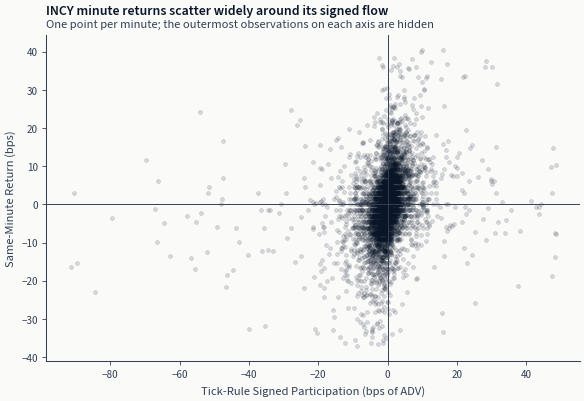

In [27]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.scatter(x[plot_idx], y[plot_idx], color=COLORS["blue"], alpha=0.15, s=8)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.7)
ax.set_xlabel("Tick-Rule Signed Participation (bps of ADV)")
ax.set_ylabel("Same-Minute Return (bps)")
add_message_title(
    ax,
    f"{rep_symbol} minute returns scatter widely around its signed flow",
    subtitle="One point per minute; the outermost observations on each axis are hidden",
)
show_with_alt(
    fig,
    "A dense scatter of one stock's minute returns against its signed participation, centred on "
    "the origin. The cloud is roughly circular with a faint upward tilt, so knowing the minute's "
    "flow narrows the range of plausible returns very little.",
)

**Interpretation**: The cloud is what a median R-squared near zero looks like. Whatever slope
runs through it, knowing a minute's signed flow barely narrows the range of returns that minute
could have had, which rules this coefficient out as a bar-level predictor. It leaves it usable
for what the impact model asks of it - an average cost over many orders - and even for that, the
ordering problem stands: the flow and the return were measured over the same minute.

## 5. Intraday Volume Profile

Participation is an order's size divided by the volume available, and volume is not spread evenly
through the day. The profile below is what an execution schedule has to work against: trading the
same number of shares at a quiet hour is a larger share of that hour's volume, and by the model
costs more.

The profile alone does not settle when to trade. Spreads are also widest at the open, and trading
alongside informed participants - **adverse selection**, where the counterparty knows something
you do not and the price keeps moving after your fill - varies through the day too. Volume says
what the denominator of the participation rate is; the other terms have to be checked separately.

In [28]:
nq_volume_profile = (
    nq_micro.filter(pl.col("volume") > 0)
    .with_columns(
        minute_of_day=(
            pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
            + pl.col("timestamp").dt.minute().cast(pl.Int32)
        ),
    )
    .group_by("minute_of_day")
    .agg(
        mean_volume=pl.col("volume").mean(),
        median_volume=pl.col("volume").median(),
    )
    .sort("minute_of_day")
)

trading_hours = nq_volume_profile.filter(
    (pl.col("minute_of_day") >= 570) & (pl.col("minute_of_day") < 960)
)
if trading_hours.is_empty():
    raise ValueError("No intraday volume profile available for the selected NASDAQ-100 sample.")

total_vol = trading_hours["mean_volume"].sum()
trading_hours = trading_hours.with_columns(
    vol_fraction=pl.col("mean_volume") / total_vol,
    time_label=(
        (pl.col("minute_of_day") // 60).cast(pl.String)
        + ":"
        + (pl.col("minute_of_day") % 60).cast(pl.String).str.zfill(2)
    ),
)

open_share = float(
    trading_hours.filter(pl.col("minute_of_day").is_between(570, 599))["vol_fraction"].sum()
)
close_share = float(
    trading_hours.filter(pl.col("minute_of_day").is_between(930, 959))["vol_fraction"].sum()
)
boundary_share = open_share + close_share

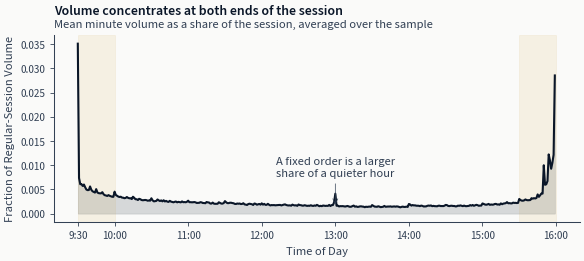

In [29]:
th_pd = trading_hours.to_pandas()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.fill_between(th_pd["minute_of_day"], th_pd["vol_fraction"], color=COLORS["blue"], alpha=0.15)
ax.plot(th_pd["minute_of_day"], th_pd["vol_fraction"], color=COLORS["blue"], linewidth=1.5)
ax.axvspan(570, 600, color=COLORS["amber"], alpha=0.12)
ax.axvspan(930, 960, color=COLORS["amber"], alpha=0.12)
ax.set(xlabel="Time of Day", ylabel="Fraction of Regular-Session Volume")
add_message_title(
    ax,
    "Volume concentrates at both ends of the session",
    subtitle="Mean minute volume as a share of the session, averaged over the sample",
)

tick_times = [570, 600, 660, 720, 780, 840, 900, 960]
ax.set_xticks(tick_times, [f"{minute // 60}:{minute % 60:02d}" for minute in tick_times])

midday_idx = th_pd.loc[th_pd["minute_of_day"].between(700, 840), "vol_fraction"]
if len(midday_idx) > 0:
    ax.annotate(
        "A fixed order is a larger\nshare of a quieter hour",
        xy=(780, midday_idx.min()),
        xytext=(780, th_pd["vol_fraction"].max() * 0.22),
        arrowprops={"arrowstyle": "->", "color": COLORS["neutral"]},
        fontsize=9,
        ha="center",
    )

show_with_alt(
    fig,
    "The share of the session's volume traded in each minute, from the open to the close. The "
    "curve is highest in the first minutes, falls through the morning to a flat midday trough, "
    "and climbs steeply into the close, giving the familiar U shape.",
)

In [30]:
display(
    Markdown(
        f"**Volume reading:** The first thirty minutes of the session carry {open_share:.1%} of "
        f"its volume and the last thirty carry {close_share:.1%}, so {boundary_share:.1%} of the "
        "day's trading happens in a sixth of its minutes. An order worked evenly through the day "
        "therefore takes a much larger share of the midday volume than of the volume at either "
        "end, which is the observation the next notebook's execution schedules are built on."
    )
)

**Volume reading:** The first thirty minutes of the session carry 17.0% of its volume and the last thirty carry 17.6%, so 34.6% of the day's trading happens in a sixth of its minutes. An order worked evenly through the day therefore takes a much larger share of the midday volume than of the volume at either end, which is the observation the next notebook's execution schedules are built on.

## 6. Bounded Capacity Scenarios

Capacity is the point where a strategy's own trading costs as much as it earns. Running more
capital means trading more of each instrument, which raises participation, which raises impact,
until the impact reaches the gross return. Everything needed to compute that is now in place: the
gross return per rebalance and the turnover it takes, both declared above, and the impact model
with its stated coefficient.

The exercise runs only on the four markets whose volume converts to dollars, and assumes the
strategy spreads its trading across instruments in proportion to how much each one trades - so
participation is the same everywhere and the universe's total daily dollar volume is the
denominator.

In [31]:
capacity_markets = ["Crypto Perps", "CME Futures", "S&P 500 Equities", "NASDAQ-100"]
capacity_rows = []
for name in capacity_markets:
    df = daily_stats[name]
    entity_col = entity_cols[name]
    per_entity = (
        df.filter(pl.col("daily_turnover_usd").is_not_null())
        .group_by(entity_col)
        .agg(mean_daily_turnover_usd=pl.col("daily_turnover_usd").mean())
    )
    capacity_rows.append(
        {
            "market": name,
            "entities": len(per_entity),
            "total_addv_usd": float(per_entity["mean_daily_turnover_usd"].sum()),
            "median_daily_sigma": float(df["sigma"].drop_nulls().median()),
            "eta_assumption": ETA_SCENARIO[name],
        }
    )

capacity_df = pl.DataFrame(capacity_rows)
capacity_df

market,entities,total_addv_usd,median_daily_sigma,eta_assumption
str,i64,f64,f64,f64
"""Crypto Perps""",19,2.8901e10,0.044091,0.3
"""CME Futures""",30,8.4908e11,0.009335,0.08
"""S&P 500 Equities""",50,7.4444e10,0.017563,0.15
"""NASDAQ-100""",50,5.8927e10,0.018784,0.12


In [32]:
unsupported_capacity = pl.DataFrame(
    {
        "market": ["ETFs", "FX Pairs"],
        "reason_excluded": [
            "Adjusted prices cannot be paired with observed shares for historical USD turnover",
            "OANDA volume is tick activity, not traded currency or dollar notional",
        ],
    }
)
unsupported_capacity

market,reason_excluded
str,str
"""ETFs""","""Adjusted prices cannot be pair…"
"""FX Pairs""","""OANDA volume is tick activity,…"


### Scenario Bounds

Two capacity numbers come out of this, and they answer different questions. The first is the
capital at which the strategy's participation reaches the ceiling declared in the settings: past
that point the square-root model is being extrapolated far outside the order sizes it was built
from, so the curve simply stops. The second is the capital at which impact equals the gross
return and the strategy earns nothing net, which exists only when that happens inside the
ceiling.

In [33]:
capacity_summary_rows = []
for row in capacity_df.iter_rows(named=True):
    max_aum = row["total_addv_usd"] * MAX_FEASIBLE_PARTICIPATION / TURNOVER_PER_REBALANCE
    breakeven_participation = (
        GROSS_ALPHA_BPS / (row["median_daily_sigma"] * row["eta_assumption"] * 10_000)
    ) ** 2
    break_even_aum = (
        breakeven_participation * row["total_addv_usd"] / TURNOVER_PER_REBALANCE
        if breakeven_participation <= MAX_FEASIBLE_PARTICIPATION
        else None
    )
    capacity_summary_rows.append(
        {
            **row,
            "max_aum_at_participation_bound": max_aum,
            "break_even_aum_within_bound": break_even_aum,
        }
    )

capacity_summary = pl.DataFrame(capacity_summary_rows)
capacity_summary

market,entities,total_addv_usd,median_daily_sigma,eta_assumption,max_aum_at_participation_bound,break_even_aum_within_bound
str,i64,f64,f64,f64,f64,f64
"""Crypto Perps""",19,2.8901e10,0.044091,0.3,1.9268e10,1.3766e10
"""CME Futures""",30,8.4908e11,0.009335,0.08,5.6605e11,null
"""S&P 500 Equities""",50,7.4444e10,0.017563,0.15,4.9630e10,null
"""NASDAQ-100""",50,5.8927e10,0.018784,0.12,3.9285e10,null


### Capacity-Curve Helper

In [34]:
def capacity_curve(row: dict, aum_grid: np.ndarray) -> np.ndarray:
    """Return net alpha per rebalance across an AUM grid, blank beyond the participation ceiling."""
    participation = aum_grid * TURNOVER_PER_REBALANCE / row["total_addv_usd"]
    feasible = participation <= MAX_FEASIBLE_PARTICIPATION
    impact_bps = row["median_daily_sigma"] * row["eta_assumption"] * np.sqrt(participation) * 10_000
    return np.where(feasible, GROSS_ALPHA_BPS - impact_bps, np.nan)

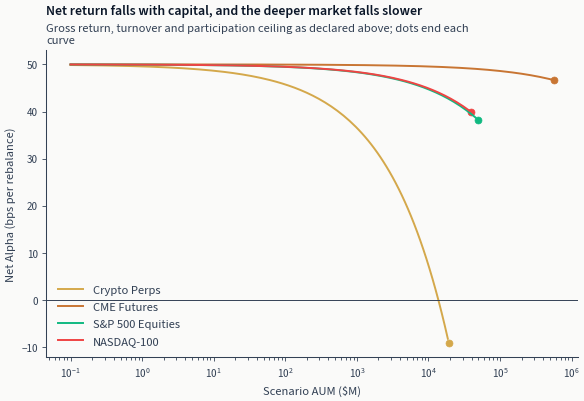

In [35]:
max_scenario_aum = float(capacity_summary["max_aum_at_participation_bound"].max())
aum_range = np.logspace(5, np.log10(max_scenario_aum * 1.15), 160)

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
for row in capacity_summary.iter_rows(named=True):
    net_alpha = capacity_curve(row, aum_range)
    color = market_colors[row["market"]]
    ax.plot(aum_range / 1e6, net_alpha, color=color, label=row["market"])
    endpoint_net = GROSS_ALPHA_BPS - (
        row["median_daily_sigma"]
        * row["eta_assumption"]
        * np.sqrt(MAX_FEASIBLE_PARTICIPATION)
        * 10_000
    )
    ax.scatter(
        row["max_aum_at_participation_bound"] / 1e6,
        endpoint_net,
        color=color,
        s=25,
    )

ax.axhline(0, color=COLORS["neutral"], linewidth=0.7)
ax.set_xscale("log")
ax.set_xlabel("Scenario AUM ($M)")
ax.set_ylabel("Net Alpha (bps per rebalance)")
add_message_title(
    ax,
    "Net return falls with capital, and the deeper market falls slower",
    subtitle="Gross return, turnover and participation ceiling as declared above; dots end each curve",
)
ax.legend(loc="lower left", fontsize=9)
show_with_alt(
    fig,
    "Four downward-sloping curves of net return per rebalance against scenario capital on a log "
    "axis, one per market, each ending in a dot at the participation ceiling. The curves are "
    "separated by orders of magnitude of capital, with CME futures furthest right.",
)

In [36]:
capacity_reading = ", ".join(
    f"{row['market']} {row['max_aum_at_participation_bound'] / 1e9:,.1f}bn"
    for row in capacity_summary.sort("max_aum_at_participation_bound").iter_rows(named=True)
)
display(
    Markdown(
        f"**Capacity reading:** At the declared participation ceiling the four curves end at "
        f"{capacity_reading} of scenario capital. The ordering follows total daily dollar volume, "
        "and every level moves proportionally with the coefficient that was assumed rather than "
        "measured, so the ranking is better founded than the levels."
    )
)

**Capacity reading:** At the declared participation ceiling the four curves end at Crypto Perps 19.3bn, NASDAQ-100 39.3bn, S&P 500 Equities 49.6bn, CME Futures 566.1bn of scenario capital. The ordering follows total daily dollar volume, and every level moves proportionally with the coefficient that was assumed rather than measured, so the ranking is better founded than the levels.

## 7. Normalize Before Comparing Model Shapes

A backtest that swaps a square-root impact model for a linear one has changed two things at once:
the shape of the cost curve and the coefficient scaling it. Comparing the results then says
nothing about which shape is right.

Setting the two models equal at one reference participation removes the scale difference, so the
only thing left between them is the shape. What that shape decides is which end of the size range
a model is pessimistic about: below the reference point the square root charges more than the
linear model, above it less. A backtest calibrated on typical order sizes and then run on much
larger ones is exactly where the difference bites.

In [37]:
etf_scenario = scenario_df.filter(pl.col("market") == "ETFs").row(0, named=True)
participation_grid = np.logspace(-3, -1, 120)
sqrt_impact = (
    etf_scenario["median_daily_sigma"]
    * etf_scenario["eta_assumption"]
    * np.sqrt(participation_grid)
)
reference_impact = (
    etf_scenario["median_daily_sigma"]
    * etf_scenario["eta_assumption"]
    * np.sqrt(MODEL_REFERENCE_PARTICIPATION)
)
linear_coefficient = reference_impact / MODEL_REFERENCE_PARTICIPATION
linear_impact = linear_coefficient * participation_grid

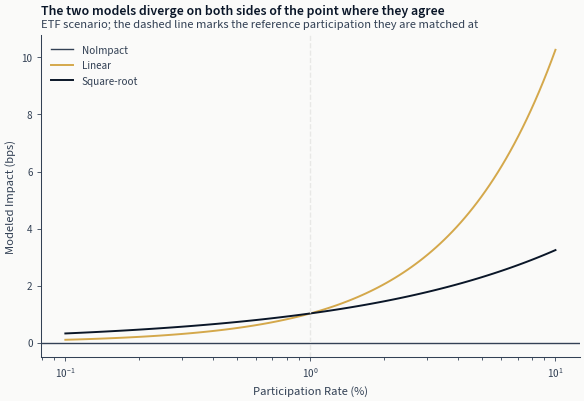

In [38]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.axhline(0, color=COLORS["neutral"], linewidth=1.0, label="NoImpact")
ax.plot(
    participation_grid * 100,
    linear_impact * 10_000,
    color=COLORS["amber"],
    label="Linear",
)
ax.plot(
    participation_grid * 100,
    sqrt_impact * 10_000,
    color=COLORS["blue"],
    label="Square-root",
)
ax.axvline(
    MODEL_REFERENCE_PARTICIPATION * 100, color=COLORS["silver_muted"], linestyle="--", linewidth=1
)
ax.set_xscale("log")
ax.set_xlabel("Participation Rate (%)")
ax.set_ylabel("Modeled Impact (bps)")
add_message_title(
    ax,
    "The two models diverge on both sides of the point where they agree",
    subtitle="ETF scenario; the dashed line marks the reference participation they are matched at",
)
ax.legend()
show_with_alt(
    fig,
    "Two impact curves against participation on a log axis, crossing at the dashed reference line. "
    "The square-root curve is above the linear one to the left of it and below it to the right, "
    "and the gap widens in both directions.",
)

In [39]:
display(
    Markdown(
        f"**Shape reading:** Both models charge {reference_impact * 10_000:.2f} bps at the "
        f"{MODEL_REFERENCE_PARTICIPATION:.0%} reference. At {participation_grid[0]:.1%} "
        f"participation the linear model charges {linear_impact[0] * 10_000:.2f} bps against the "
        f"square root's {sqrt_impact[0] * 10_000:.2f}; at {participation_grid[-1]:.0%} it charges "
        f"{linear_impact[-1] * 10_000:.2f} against {sqrt_impact[-1] * 10_000:.2f}. Choosing the "
        "linear model understates the cost of small orders and overstates the cost of large ones."
    )
)

**Shape reading:** Both models charge 1.03 bps at the 1% reference. At 0.1% participation the linear model charges 0.10 bps against the square root's 0.32; at 10% it charges 10.27 against 3.25. Choosing the linear model understates the cost of small orders and overstates the cost of large ones.

## 8. Where Market Stress Enters the Model

In $I = \sigma \cdot \eta \cdot \sqrt{Q/V}$, only $\sigma$ is a market-state variable. A
strategy that trades the same participation in a stressed market pays more because the volatility
it is scaling has risen, and the model says that happens even if nothing about market depth or
the coefficient has changed at all.

This section isolates that one channel. The coefficient stays at the ETF value stated in Section
2 and participation stays at the reference rate, so the only thing varying between the four bars
is the median volatility of the days in each bucket. The buckets are quartiles of the VIX over
its whole history, which makes them a description of what happened rather than a rule a strategy
could have applied on the day.

In [40]:
macro = load_macro(series=["vixcls"])
vix = (
    macro.select(
        pl.col("timestamp").cast(pl.Date),
        pl.col("vixcls").alias("vix"),
    )
    .filter(pl.col("vix").is_not_null())
    .sort("timestamp")
)

vix_q25, vix_q50, vix_q75 = (
    vix["vix"].quantile(0.25),
    vix["vix"].quantile(0.5),
    vix["vix"].quantile(0.75),
)

In [41]:
etf_vix = (
    daily_stats["ETFs"]
    .join(vix, on="timestamp", how="inner")
    .with_columns(
        vix_regime=pl.when(pl.col("vix") < vix_q25)
        .then(pl.lit("Q1 (Low)"))
        .when(pl.col("vix") < vix_q50)
        .then(pl.lit("Q2"))
        .when(pl.col("vix") < vix_q75)
        .then(pl.lit("Q3"))
        .otherwise(pl.lit("Q4 (High)")),
    )
)

eta_base = ETA_SCENARIO["ETFs"]

### Regime-Specific Impact Helper

In [42]:
def regime_impact_row(regime: str) -> dict:
    """Model impact at the reference participation from one VIX bucket's median volatility."""
    subset = etf_vix.filter(
        (pl.col("vix_regime") == regime)
        & pl.col("ret").is_not_null()
        & pl.col("sigma").is_not_null()
        & (pl.col("sigma") > 0)
    )
    med_sigma = subset["sigma"].median()
    if med_sigma is None:
        return {
            "regime": regime,
            "median_daily_sigma": np.nan,
            "impact_ref_bps": np.nan,
            "observations": len(subset),
        }
    impact_ref = med_sigma * eta_base * np.sqrt(MODEL_REFERENCE_PARTICIPATION) * 10_000
    return {
        "regime": regime,
        "median_daily_sigma": med_sigma,
        "impact_ref_bps": impact_ref,
        "observations": len(subset),
    }

In [43]:
regimes = ["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
regime_df = pl.DataFrame([regime_impact_row(regime) for regime in regimes])
if (
    regime_df["impact_ref_bps"].null_count()
    or not np.isfinite(regime_df["impact_ref_bps"].to_numpy()).all()
):
    raise ValueError("Every VIX bucket needs a finite modeled impact estimate")

regime_df

regime,median_daily_sigma,impact_ref_bps,observations
str,f64,f64,i64
"""Q1 (Low)""",0.007682,0.76823,62516
"""Q2""",0.009244,0.924439,64799
"""Q3""",0.01132,1.131977,55779
"""Q4 (High)""",0.016617,1.661688,52172


Reading the bars: the height of each one is the model's output, not a measurement of what trading
cost in that state. It answers "how much more would the same order cost if only volatility
changed", and the answer to "how much more did it actually cost" would need execution records
from those days, which is the same thing Section 2 said was missing.

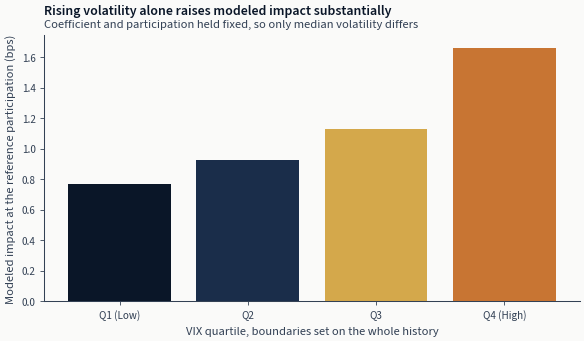

In [44]:
impacts = regime_df["impact_ref_bps"].to_numpy()
impact_ratio = impacts[-1] / impacts[0]

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
colors = [COLORS["blue"], COLORS["slate"], COLORS["amber"], COLORS["copper"]]
ax.bar(regimes, impacts, color=colors)
ax.set_ylabel("Modeled impact at the reference participation (bps)")
ax.set_xlabel("VIX quartile, boundaries set on the whole history")
add_message_title(
    ax,
    "Rising volatility alone raises modeled impact substantially",
    subtitle="Coefficient and participation held fixed, so only median volatility differs",
)

show_with_alt(
    fig,
    "Four bars of modeled impact, one per VIX quartile, rising from the calmest to the most "
    "stressed. The most stressed bar is roughly twice the height of the calmest.",
)

In [45]:
display(
    Markdown(
        f"**Retrospective reading:** With the coefficient fixed at {eta_base:.2f}, modeled impact "
        f"at the reference participation rises from {impacts[0]:.2f} bps in the calmest VIX "
        f"quartile to {impacts[-1]:.2f} bps in the most stressed, a factor of "
        f"{impact_ratio:.2f}. Every part of that comes from the volatility term."
    )
)

**Retrospective reading:** With the coefficient fixed at 0.10, modeled impact at the reference participation rises from 0.77 bps in the calmest VIX quartile to 1.66 bps in the most stressed, a factor of 2.16. Every part of that comes from the volatility term.

In [46]:
low_scenario = scenario_df.sort("impact_ref_bps").row(0, named=True)
high_scenario = scenario_df.sort("impact_ref_bps").row(-1, named=True)
display(
    Markdown(
        f"At the reference participation the six scenarios span "
        f"{low_scenario['impact_ref_bps']:.2f} bps for {low_scenario['market']} to "
        f"{high_scenario['impact_ref_bps']:.2f} bps for {high_scenario['market']}. Across "
        f"{len(lambda_df)} minute-level regressions the median slope is {median_lambda:.3f} "
        f"return bps per basis point of signed participation at a median R-squared of "
        f"{median_r2:.4f}, and the cross-sectional slope against dollar turnover is {slope:.2f} "
        f"with a 95% interval from {slope_low:.2f} to {slope_high:.2f}. The first and last thirty "
        f"minutes of the session carry {boundary_share:.1%} of its volume."
    )
)

At the reference participation the six scenarios span 0.24 bps for FX Pairs to 13.24 bps for Crypto Perps. Across 100 minute-level regressions the median slope is 0.039 return bps per basis point of signed participation at a median R-squared of -0.0033, and the cross-sectional slope against dollar turnover is -0.00 with a 95% interval from -0.26 to 0.25. The first and last thirty minutes of the session carry 34.6% of its volume.

## Key Takeaways

1. **Find out which of a cost model's inputs you can measure before you use it.** Volatility,
   volume and order size come off market data. The impact coefficient does not: it is the ratio
   of what your orders paid to what the price was when you decided to send them, and without
   execution records of your own it is an assumption however precisely you quote it.

2. **Two quantities measured over the same interval cannot establish that one caused the other.**
   Signed flow and return in the same minute move together, and a piece of news arriving in that
   minute produces both. Separating temporary from permanent impact takes data on what happened
   after the order stopped, which minute bars do not carry.

3. **Read a cross-sectional slope with its interval, and check what was dropped to fit it.** A
   slope with the sign the theory predicts is not evidence when the interval around it contains
   zero, and taking logs of a coefficient silently excludes every instrument whose estimate came
   out negative. Report that count next to the slope.

4. **A robust fit and an R-squared answer to different criteria.** Huber regression caps the
   influence of extreme observations, so its line does not minimize squared error and the
   R-squared beside it can be negative. Read that as a property of the estimator, not a broken
   fit, and do not switch to least squares to make the number look better.

5. **Compute participation against the volume in the interval you actually trade in.** Volume is
   concentrated at the open and the close, so the same order is a much larger share of a midday
   hour than a daily average implies. A cost estimate built on daily volume understates what an
   order worked through the quiet part of the day pays.

6. **Match cost models at a reference point before comparing their shapes.** A linear and a
   square-root model with different coefficients differ in two ways at once. Set them equal
   somewhere and the remaining difference is the shape, which is what decides whether a model
   calibrated on ordinary orders is optimistic or pessimistic about large ones.

7. **State the capital, turnover and participation limit a capacity number rests on.** Capacity
   is not a property of a market: it is the point where a stated gross return meets a modeled
   cost, and changing any of the three inputs moves it.

### Known limitations

- The impact coefficients are stated, not estimated. Every impact and capacity level in the
  notebook scales directly with them, so the orderings are better founded than the levels.
- The minute-level regressions cover one quarter of one market. Volatility, and with it the
  relationship between flow and returns, differs across periods.
- Trade direction comes from the tick rule, which misclassifies trades inside the spread and at
  the touch. A misclassified minute enters the regression with the wrong sign on its flow.
- The volatility and volume windows end on the day being described, so they summarize the sample
  rather than what a strategy would have known that morning.
- The capacity exercise assumes trading spread across each universe in proportion to dollar
  volume, and one shared participation rate. A strategy concentrated in a few names hits its
  capacity far sooner than these curves suggest.
- The participation ceiling extends the square-root model well beyond the order sizes it was
  built from. Where the curves end is a stated limit, not a measured one.

**Next:** `04_vwap_twap_execution` builds the execution schedules that spread an order across the
volume profile shown here.

**Book:** Chapter 18, Sections 18.3, 18.4 and 18.8.